# Generating efficient workflows for operator backpropagation (OBP) in a quantum-centric supercomputing (QCSC) software stack
*Usage estimate: 2 minutes on IBM Fez (NOTE: This is an estimate only. Your runtime may vary.)*


## Background

Operator Backpropagation (OBP) is a technique used to reduce the depth of quantum circuits by allowing deeper transformations into the circuit, at the cost of increasing the complexity of the observable. To obtain meaningful results using OBP, it is often necessary to truncate terms in the observable to prevent it from becoming too large. One effective strategy for managing observable growth is to omit terms with small coefficients, instead of including them in the operator. This reduces the number of quantum circuits that need to be executed, though it introduces an approximation error in the final expectation value that is proportional to the sum of the coefficients of the discarded terms. More details on truncation can be found in the corresponding [guide](https://qiskit.github.io/qiskit-addon-obp/how_tos/truncate_operator_terms.html) with a simple example to get started.  

The `backpropagate` method accepts an optional [TruncationErrorBudget](https://qiskit.github.io/qiskit-addon-obp/apidocs/qiskit_addon_obp.utils.truncating.html#qiskit_addon_obp.utils.truncating.TruncationErrorBudget) parameter, which configures how low-weight Pauli terms are truncated after each successful backpropagation slice. The number of terms truncated depends on various user-defined configuration parameters.
Currently, a single truncation strategy is implemented: the [truncate_binary_search](https://qiskit.github.io/qiskit-addon-obp/apidocs/qiskit_addon_obp.utils.truncating.html#qiskit_addon_obp.utils.truncating.truncate_binary_search) method. This approach performs a binary search over the Pauli terms and their coefficients in the observable to identify an optimal threshold. The goal is to maximize the sum of the coefficients of the truncated terms, without exceeding the specified error budget.

There exist various approaches of performing truncation, each with its own trade-offs and applicability depending on the context. Selecting an appropriate truncation method is crucial, as it influences both the efficiency of the quantum circuit execution and the accuracy of the resulting expectation values.

1. `max_error_per_slice` : if `max_error_per_slice` is provided, its value is converted into a list and used directly to configure the truncation budget in [TruncationErrorBudget.per_slice_budget](https://qiskit.github.io/qiskit-addon-obp/apidocs/qiskit_addon_obp.utils.truncating.html#qiskit_addon_obp.utils.truncating.TruncationErrorBudget.per_slice_budget)
   
2. `max_error_total` without `num_slices` given : The `max_error_total` must be specified now, if `num_slices` is **not** provided, the entire error budget is assigned to a single slice, meaning [TruncationErrorBudget.per_slice_budget](https://qiskit.github.io/qiskit-addon-obp/apidocs/qiskit_addon_obp.utils.truncating.html#qiskit_addon_obp.utils.truncating.TruncationErrorBudget.per_slice_budget) defaults to `max_error_total`. In this case, the full error allowance is consumed **greedily**.

3. `max_error_total` with `num_slices` given : However, if `num_slices` is specified, the [TruncationErrorBudget.per_slice_budget](https://qiskit.github.io/qiskit-addon-obp/apidocs/qiskit_addon_obp.utils.truncating.html#qiskit_addon_obp.utils.truncating.TruncationErrorBudget.per_slice_budget) is computed by evenly distributing the maximum allowable total error across the defined number of slices, i.e., `max_error_total / num_slices`.

Selecting the optimal truncation method among the three available approaches is non-trivial. Therefore, during operator backpropagation, we apply all three truncation strategies and select the one that yields the circuit with the lowest depth. While this process can be performed sequentially, it can significantly increase classical computation time. To reduce this and improve efficiency, we leverage a serverless execution model, allowing the methods to run in parallel.

**Qiskit Serverless** is a framework that helps you run quantum and classical tasks at scale without managing the underlying infrastructure. It allows long-running quantum jobs to be executed in parallel across different types of hardware, such as CPUs, GPUs, and QPUs. The system automatically takes care of resource allocation, scaling, and job scheduling, so you don’t need to configure anything manually. This makes it easier to work with complex quantum-classical workflows while focusing on the development of your algorithms rather than the execution environment.

![qs_diagram.png](qs_diagram.png)

This figure is taken from the [Qiskit Serverless](https://github.com/Qiskit/qiskit-serverless/tree/main) GitHub.

## Requirements
Before starting this tutorial, be sure you have the following installed:

* Qiskit SDK 2.0 or later with visualization support (`pip install qiskit[visualization]`)
* Qiskit Runtime 0.40 or later (`pip install qiskit-ibm-runtime`)
* Qiskit addon: operator backpropagation (OBP) (`pip install qiskit-addon-obp`)
* Qiskit addon utils (`pip install qiskit-addon-utils`)
* Serverless 0.25.1 or later (`pip install qiskit-ibm-catalog qiskit_serverless`)
* Rustworkx 0.16 or later (`pip install rustworkx`)


## Large-scale Heisenberg spin chain

### Step 1: Map classical inputs to a quantum problem

#### Map the time-evolution of a quantum Heisenberg model to a quantum experiment.

The [qiskit\_addon\_utils](https://github.com/Qiskit/qiskit-addon-utils) package provides some reusable functionalities for various purposes.

Its [qiskit\_addon\_utils.problem\_generators](https://docs.quantum.ibm.com/api/qiskit-addon-utils/problem-generators) module provides functions to generate Heisenberg-like Hamiltonians on a given connectivity graph.
This graph can be either a [rustworkx.PyGraph](https://www.rustworkx.org/apiref/rustworkx.PyGraph.html) or a [CouplingMap](https://docs.quantum.ibm.com/api/qiskit/qiskit.transpiler.CouplingMap) making it easy to use in Qiskit-centric workflows.

In the following, we generate a linear chain `CouplingMap` of 50 qubits.

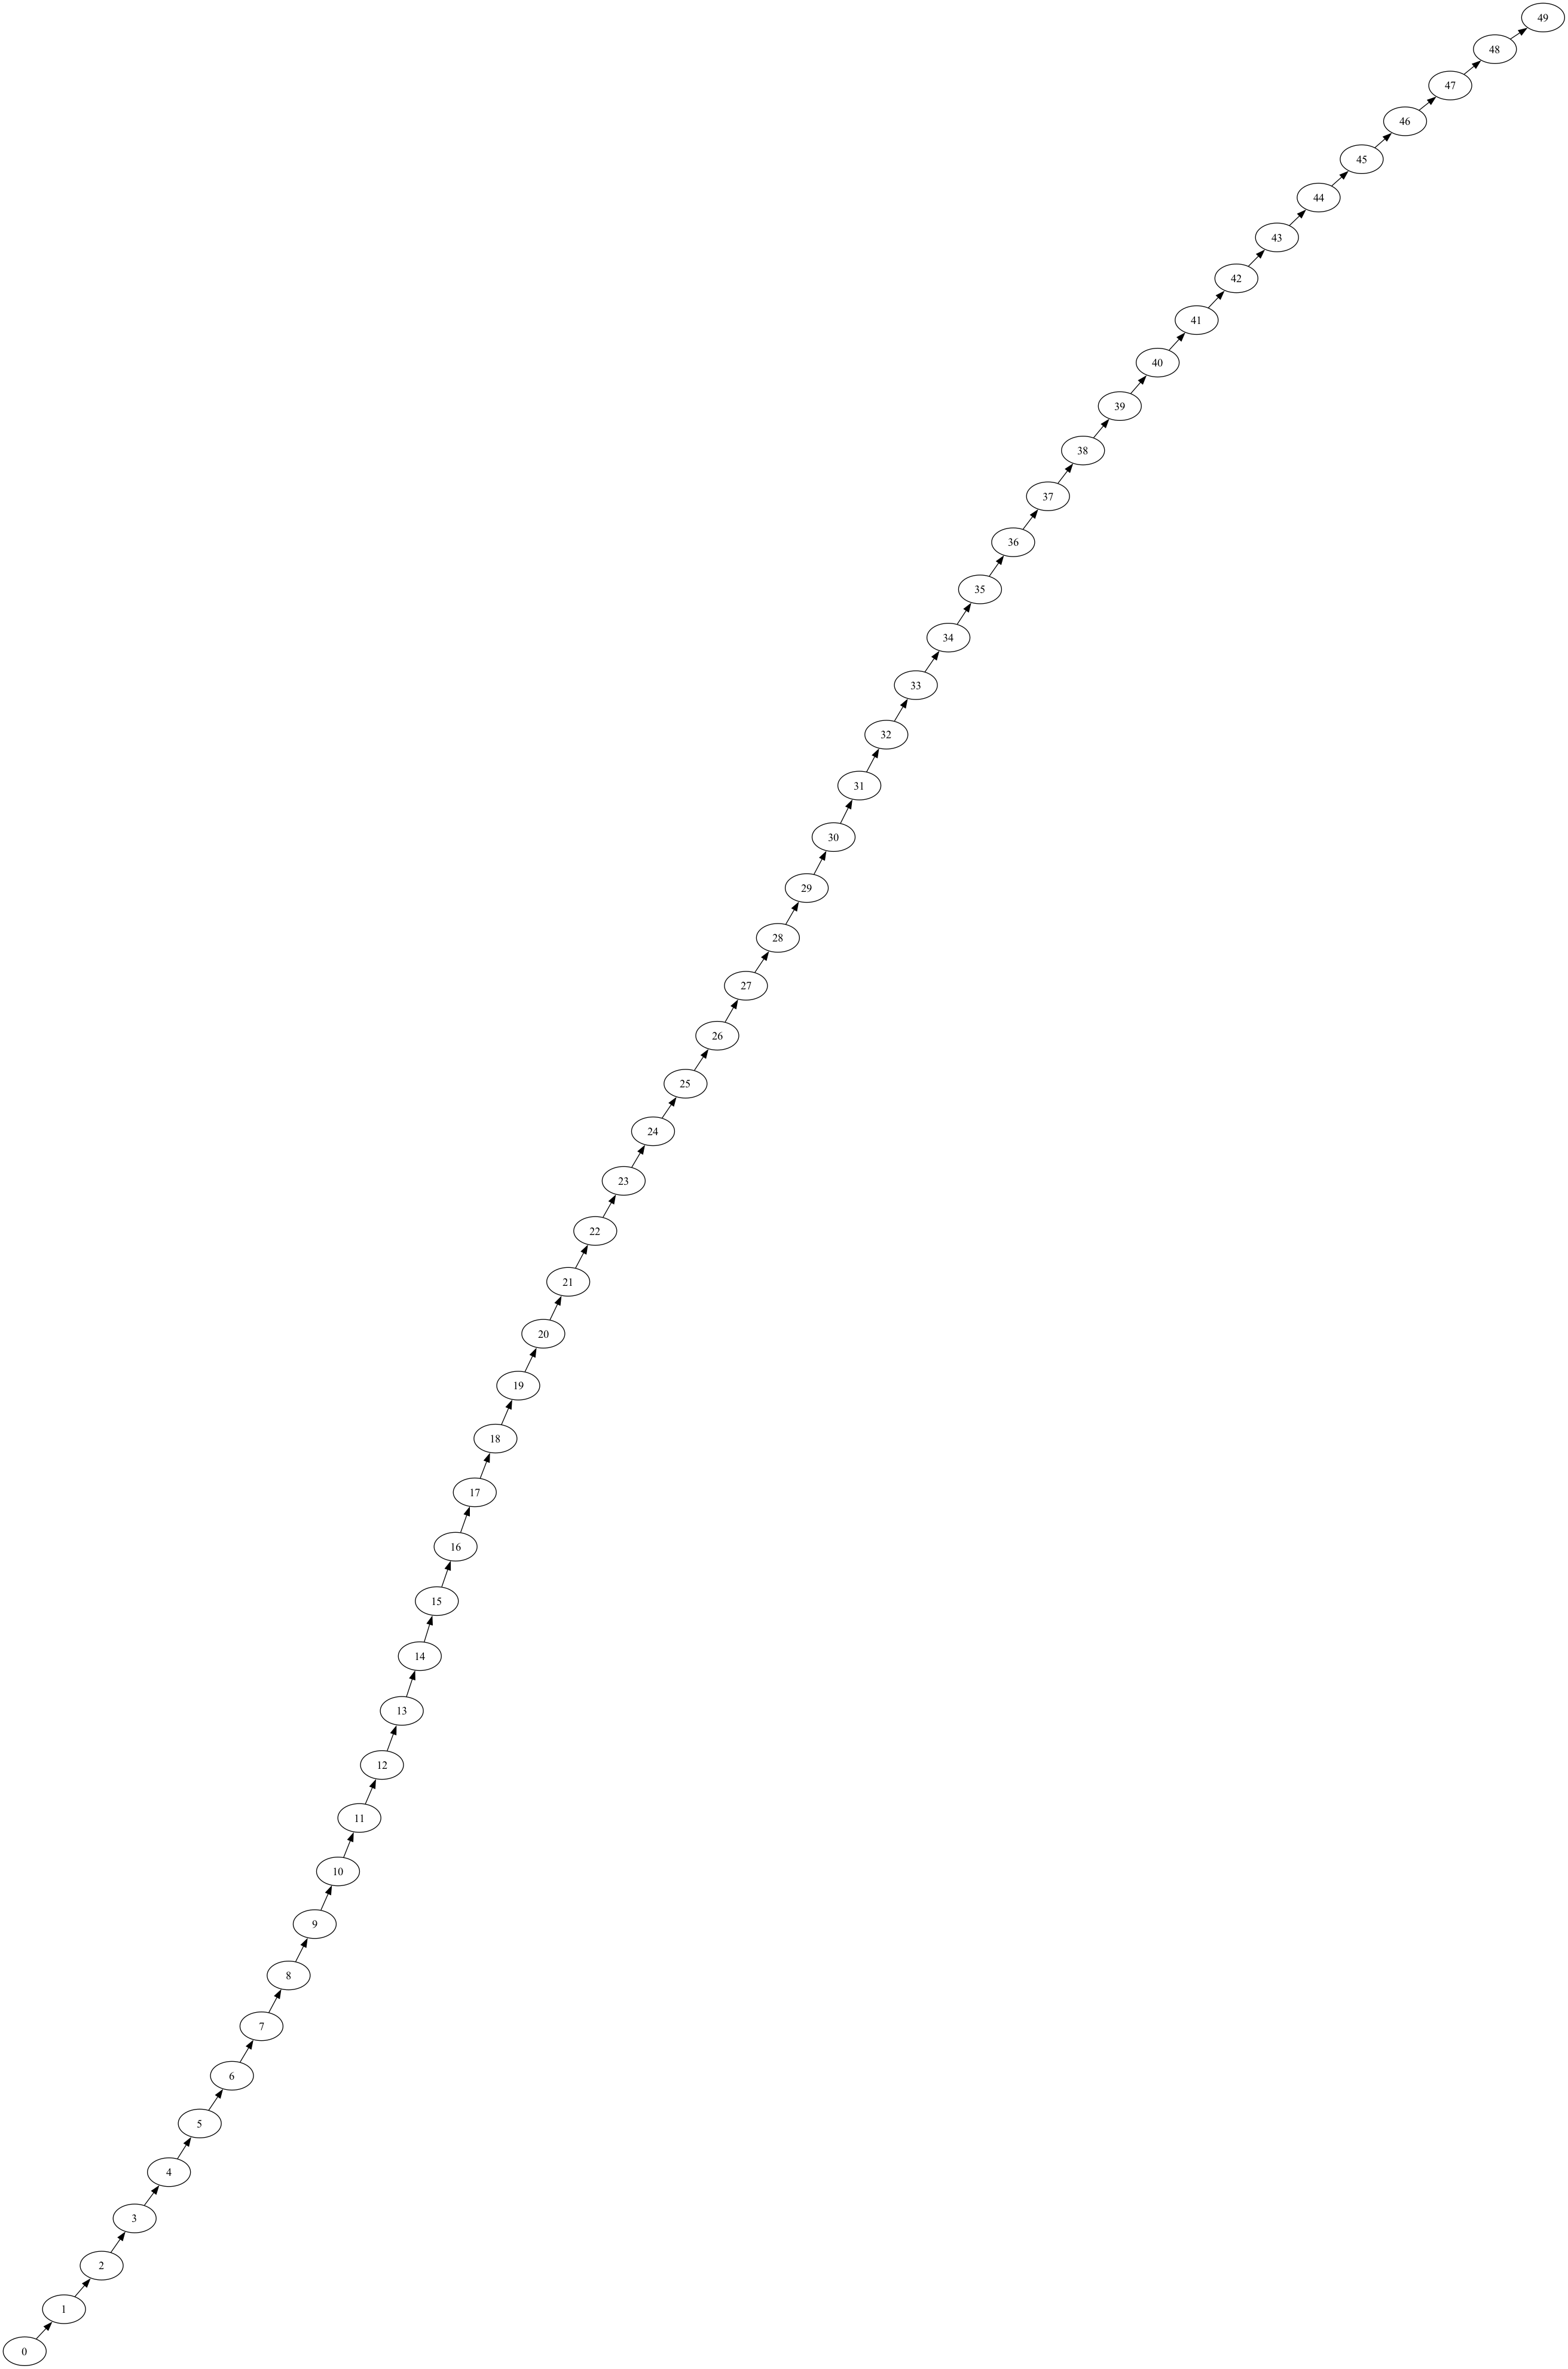

In [11]:
from qiskit.transpiler import CouplingMap
from rustworkx.visualization import graphviz_draw

num_qubits = 50
layout = [(i-1,i) for i in range(1, num_qubits)]

# Instantiate a CouplingMap object
coupling_map = CouplingMap(layout)
graphviz_draw(coupling_map.graph, method="neato")

Next, we generate a Pauli operator modeling a Heisenberg XYZ Hamiltonian.

$$
{\hat{\mathcal{H}}_{XYZ} = \sum_{(j,k)\in E} (J_{x} \sigma_j^{x} \sigma_{k}^{x} + J_{y} \sigma_j^{y} \sigma_{k}^{y} + J_{z} \sigma_j^{z} \sigma_{k}^{z}) + \sum_{j\in V} (h_{x} \sigma_j^{x} + h_{y} \sigma_j^{y} + h_{z} \sigma_j^{z})}
$$

Here we have considered a 50-qubit Hamiltonian $\hat{\mathcal{H}}_{XYZ}$. The time evolution of this hamiltonian is beyond classical brute-force simulation.


In [9]:
import numpy as np
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian

# Get a qubit operator describing the Heisenberg XYZ model
hamiltonian = generate_xyz_hamiltonian(
    coupling_map,
    coupling_constants=(np.pi / 8, np.pi / 4, np.pi / 2),
    ext_magnetic_field=(np.pi / 3, np.pi / 6, np.pi / 9),
)
print(hamiltonian)

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIII', 'IIIIIIIIIIII

From the qubit operator, we can generate a quantum circuit which models its time evolution.
Once again, the [qiskit\_addon\_utils.problem\_generators](https://docs.quantum.ibm.com/api/qiskit-addon-utils/problem-generators) module comes to the rescue with a handy function do just that:

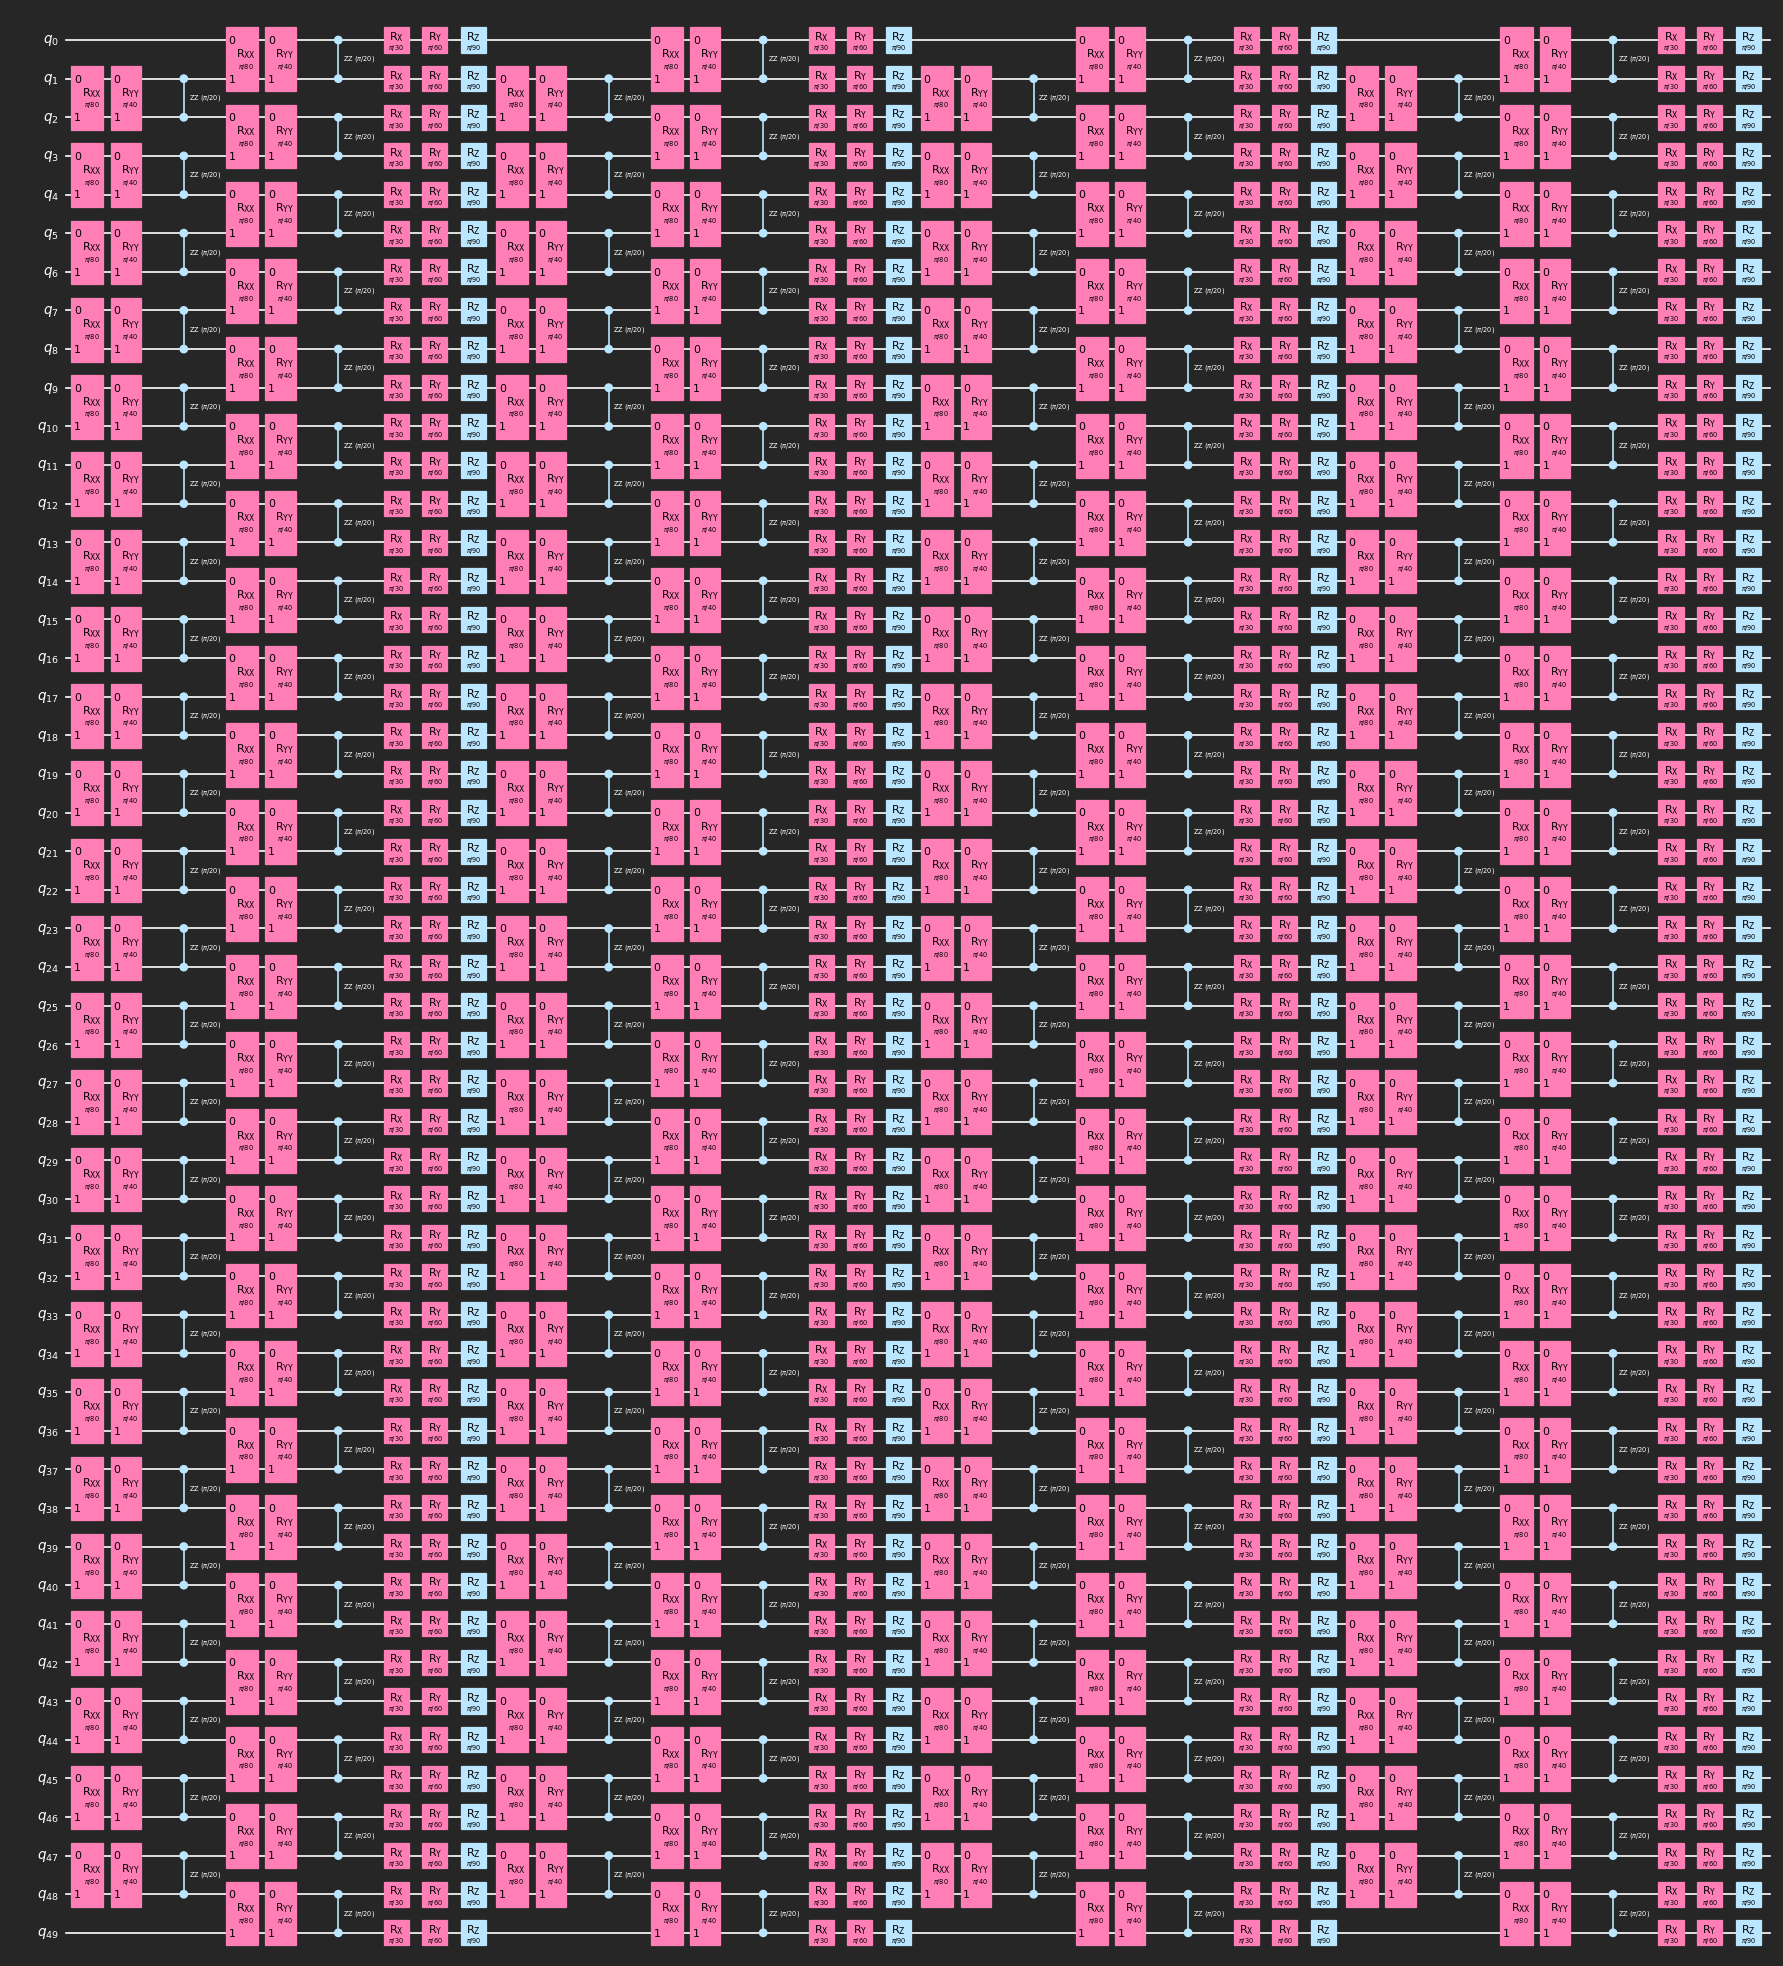

In [13]:
from qiskit.synthesis import LieTrotter
from qiskit_addon_utils.problem_generators import generate_time_evolution_circuit

circuit = generate_time_evolution_circuit(
    hamiltonian,
    time=0.2,
    synthesis=LieTrotter(reps=4),
)
circuit.draw("mpl", style="iqp-dark", fold=-1, scale=0.6)

### Step 2: Optimize circuits for quantum hardware execution

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

INTERNAL_API_KEY="<your_token>"
INTERNAL_CRN="<your_api>"

service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=INTERNAL_API_KEY,
    instance=INTERNAL_CRN
    )
backend = service.least_busy(operational=True, simulator=False)
backend

<IBMBackend('ibm_pinguino2')>

#### Decompose the circuit into basis gate set

First we `decompose` the original circuit into the basis gate set of the backend. For certain circuits, this is shown to yield better backpropagation, and for others this matches the backpropagation of the original circuit (which may contains gates outside the basis gate set).

In [25]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm_basis = generate_preset_pass_manager(optimization_level = 3, basis_gates= backend.configuration().basis_gates)
basis_circuit = pm_basis.run(circuit)

#### Create circuit slices to backpropagate

Backpropagation first partitions the circuit into non-disjoint slices, and then the `backpropagate` function moves through one slice at a time, updating the observable in the process. In this tutorial we shall slice the circuit by depth. For a more detailed discussion on circuit slicing, and other types of slicing, check this [how-to guide](https://qiskit.github.io/qiskit-addon-utils/how_tos/create_circuit_slices.html).

In [26]:
from qiskit_addon_utils.slicing import slice_by_depth

slices = slice_by_depth(basis_circuit, max_slice_depth = 1)
print(f"Separated the circuit into {len(slices)} slices.")

Separated the circuit into 107 slices.


#### Constrain how large the operator may grow during backpropagation

During backpropagation, the number of terms in the operator will generally approach $4^N$ quickly, where $N$ is the number of qubits. When two terms in the operator do not commute qubit-wise, we need separate circuits to obtain the expectation values corresponding to them. For example, if we have a 2-qubit observable $O = 0.1 XX + 0.3 IZ - 0.5 IX$, then since $[XX,IX] = 0$, measurement in a single basis is sufficient to calculate the expectation values for these two terms. However, $IZ$ anti-commutes with the other two terms. So we need a separate basis measurement to calculate the expectation value of $IZ$. In other words, we need two, instead of one, circuit to calculate $\langle O \rangle$. As the number of terms in the operator increase, there is a possibility that the required number of circuit executions also increase.

The size of the operator can be bounded by specifying the `operator_budget` kwarg of the `backpropagate` function, which accepts an [OperatorBudget](https://docs.quantum.ibm.com/api/qiskit-addon-obp/utils-simplify#operatorbudget) instance.

To control the amount of extra resources (time) allocated, we restrict the maximum number of qubit-wise commuting Pauli groups that the backpropagated observable is allowed to have. Here we specify that backpropagation should stop when the number of qubit-wise commuting Pauli groups in the operator grows past 12.


In [27]:
from qiskit_addon_obp.utils.simplify import OperatorBudget

max_qwc_groups = 12
op_budget = OperatorBudget(max_qwc_groups=max_qwc_groups)

#### Backpropagate slices from the circuit

First we specify the observable to be $M_Z = \frac{1}{N} \sum_{i=1}^NZ_i$, $N$ being the nunber of qubits. We will backpropagate slices from the time-evolution circuit until the terms in the observable can no longer be combined into 12 or fewer qubit-wise commuting Pauli groups.

In [28]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1/num_qubits) for i in range(num_qubits)], num_qubits=num_qubits
)
observable

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIII', 'IIIIIIIIIIII

For this scaled up problem we have considered the time of evolution as 0.2 with 4 trotter steps. The problem is selected so that it is beyond classical brute-force simulation, but can be simulated by tensor network method. This allows us to verify the outcome obtained via backpropagation on a quantum computer with the ideal outcome.

The ideal expectation value for this problem, as obtained via tensor network simulation, is $\simeq$ 0.89.

Below you will see that we backpropagated 19 slices, and the terms were combined into 8 and not 12 groups. This implies that backpropagating one more slice would cause the number of Pauli groups to exceed 12. We can verify that this is the case by inspecting the returned metadata. Also note that in this portion the circuit transformation is exact, i.e., no terms of the new observable $O’$ were truncated. The backpropagated circuit and the backpropagated operator gives the exact outcome as the original circuit and operator.

Backpropagated 18 slices.
New observable has 300 terms, which can be combined into 8 groups.
Note that backpropagating one more slice would result in 634 terms across 22 groups.
The remaining circuit after backpropagation looks as follows:


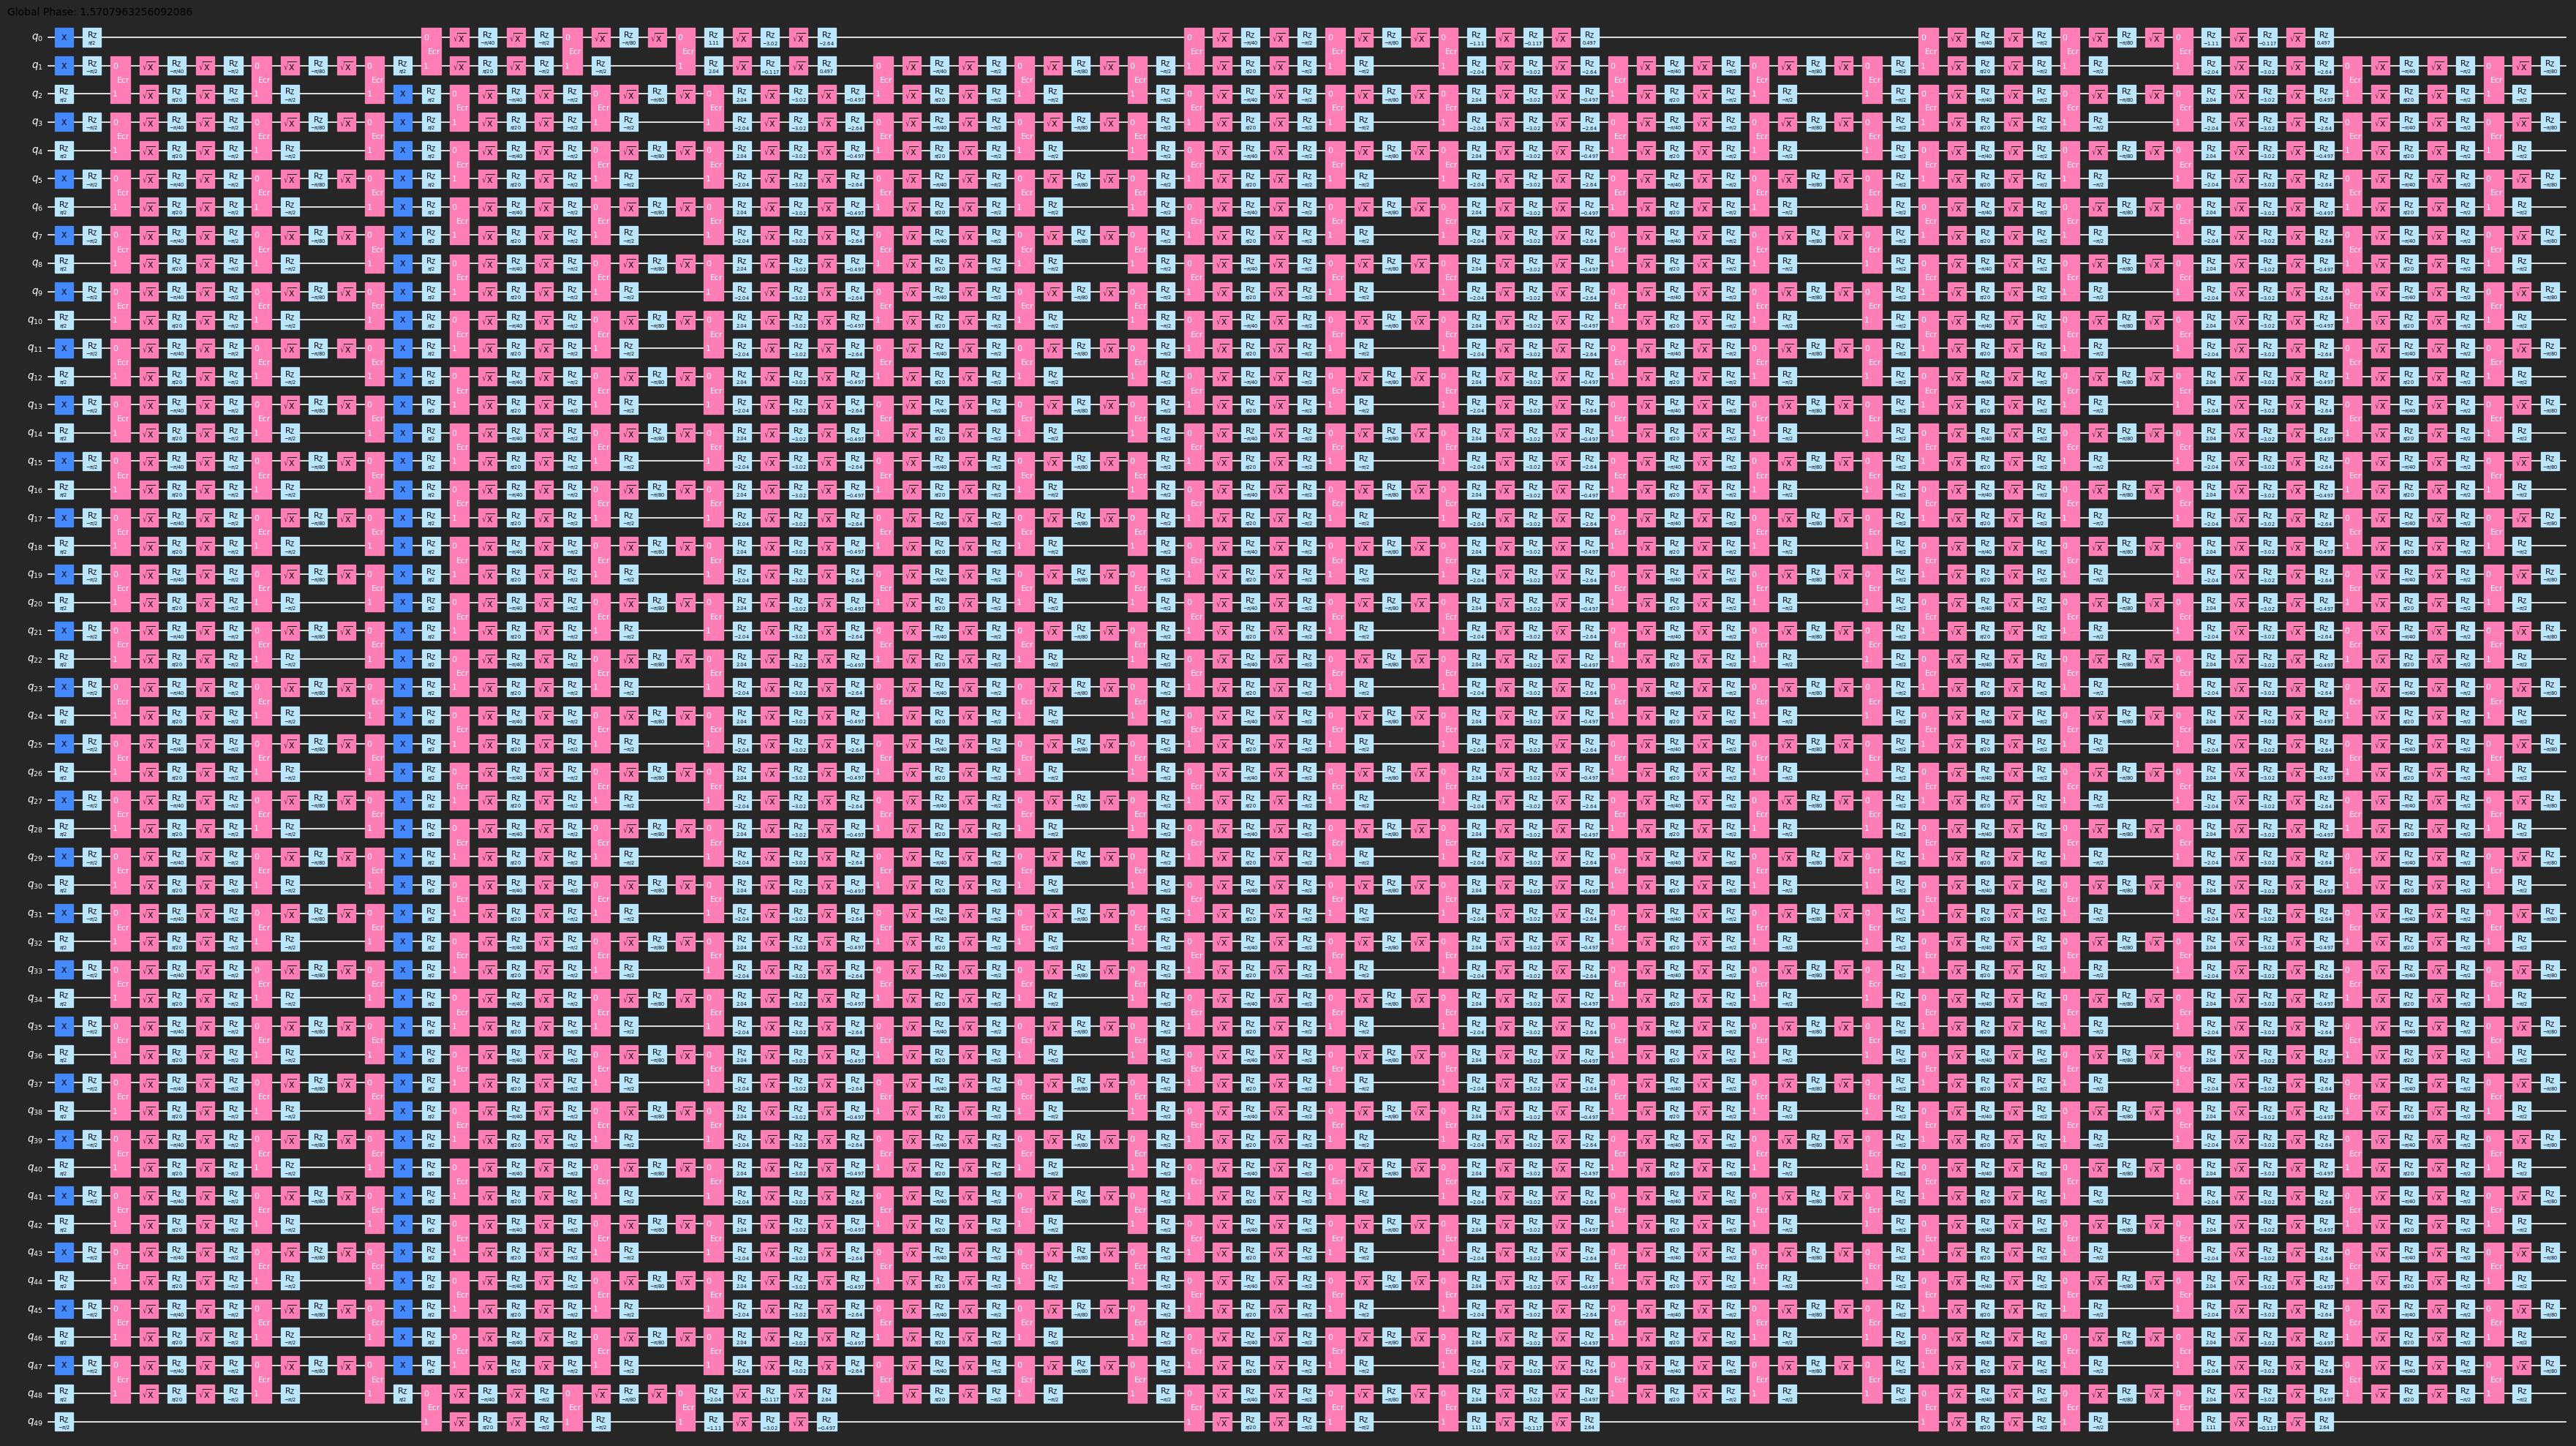

In [29]:
from qiskit.quantum_info import SparsePauliOp
from qiskit_addon_obp import backpropagate
from qiskit_addon_utils.slicing import combine_slices

# Backpropagate slices onto the observable
bp_obs, remaining_slices, metadata = backpropagate(observable, slices, operator_budget=op_budget)
# Recombine the slices remaining after backpropagation
bp_circuit = combine_slices(remaining_slices)
num_slices = metadata.num_backpropagated_slices
print(f"Backpropagated {metadata.num_backpropagated_slices} slices.")
print(
    f"New observable has {len(bp_obs.paulis)} terms, which can be combined into {len(bp_obs.group_commuting(qubit_wise=True))} groups."
)
print(
    f"Note that backpropagating one more slice would result in {metadata.backpropagation_history[-1].num_paulis[0]} terms "
    f"across {metadata.backpropagation_history[-1].num_qwc_groups} groups."
)
print("The remaining circuit after backpropagation looks as follows:")
bp_circuit.draw("mpl", fold=-1, scale=0.6, style='iqp-dark')

Next, we will specify the same problem with the same constraints on the size of the output observable. However, this time, we allot an error budget using the [setup\_budget](https://docs.quantum.ibm.com/api/qiskit-addon-obp/utils-truncating#setup_budget) function. Pauli terms with small coefficients will be truncated from each slice until the error budget is filled, and leftover budget will be added to the following slice's budget. Note that in this case, the transformation due to backpropagation is approximate since some of the terms in the operator are truncated.

For this problem, we have set the maximum truncation error per slice to be 0.005. Therefore, the maximum total truncation error for backpropagation is $0.005 \times 19=0.095$, since the number of backpropagated slices is 19.

In [30]:
from qiskit_addon_obp.utils.truncating import setup_budget

max_error_per_slice = 0.005 
max_error_total = max_error_per_slice * num_slices

In [31]:
print(f"The value of the max error per slice is {max_error_per_slice}")

The value of the max error per slice is 0.005


In [32]:
print(f"The value of the max error total is {max_error_total}")

The value of the max error total is 0.09


#### Using Qiskit Serverless to parallelize the different types of truncation errors workflows

Qiskit Serverless requires organizing the workload’s `.py` files within a dedicated directory. The following code cell represents a Python file. The name of the file is `backpropagate_remote.py`, located in the `source_files` directory. This file contains the function responsible for backpropagation.

This method leverages Qiskit Serverless to simultaneously backpropagate with different truncation methods and returns the circuit with the lowest depth. Using Qiskit Serverless here allows us to parallelize this step, hence reducing the classical simulation time.

In [81]:
%%writefile source_files/backpropagate_remote.py

from qiskit_addon_obp import backpropagate
from qiskit_addon_utils.slicing import combine_slices
from qiskit_addon_obp.utils.simplify import OperatorBudget
from qiskit_addon_obp.utils.truncating import setup_budget
from typing import List
from qiskit_serverless import get_arguments, save_result, get


def backpropagate_remote(observable:List, slices_synth:str, max_qwc_groups: int, error_type: str, error_val: float, num_slices: int):
    
    if error_type == "max_error_per_slice":
        truncation_error_budget=setup_budget(max_error_per_slice=error_val)
        
    elif error_type == "max_error_total_without_num_slices":
        truncation_error_budget=setup_budget(max_error_total=error_val)
        
    elif error_type == "max_error_total_with_num_slices":
        truncation_error_budget=setup_budget(max_error_total=error_val, num_slices = num_slices)
        
    truncated_backpropagated_observable, remaining_truncated_slices, truncated_metadata = backpropagate(
        observables=observable,
        slices=slices_synth,
        operator_budget=OperatorBudget(max_qwc_groups=max_qwc_groups),
        truncation_error_budget = truncation_error_budget
    )
    bp_circuit_trunc = combine_slices(
    remaining_truncated_slices, include_barriers=False
    )
    return (bp_circuit_trunc, truncated_backpropagated_observable)


arguments = get_arguments()
observable= arguments.get("observable")
slices_synth=arguments.get("slices_synth") 
max_qwc_groups = arguments.get("max_qwc_groups")
errors = arguments.get("errors") 
num_slices = arguments.get("num_slices")


results = [
    backpropagate_remote(observable, slices_synth, max_qwc_groups, error_type, error_val, num_slices)
    for error_type, error_val in errors.items()
]
save_result({
    "truncated_circuit": results
})

Overwriting source_files/backpropagate_remote.py


In [82]:
from qiskit_ibm_catalog import QiskitServerless, QiskitFunction

serverless = QiskitServerless(
    channel="ibm_quantum_platform"
)

In [83]:
backpropagate_remote_demo = QiskitFunction(
    title="backpropagate_remote_serverless",
    entrypoint="backpropagate_remote.py",
    working_dir="./source_files/",
    dependencies=["qiskit-addon-obp", "qiskit-addon-utils"]
)
serverless.upload(backpropagate_remote_demo)
backpropagate_remote_serverless = serverless.load("backpropagate_remote_serverless")

In [84]:
job_different_truncation = backpropagate_remote_serverless.run(
    observable=observable,
    slices_synth=slices, 
    max_qwc_groups=max_qwc_groups,
    errors={"max_error_per_slice": max_error_per_slice, "max_error_total_without_num_slices" :max_error_total, "max_error_total_with_num_slices" : max_error_total},
    num_slices = num_slices
)

In [85]:
job_different_truncation.job_id

'975bb7aa-1373-4b37-b94f-7689b8b194da'

In [88]:
job_different_truncation.status()

'DONE'

In [89]:
results = job_different_truncation.result()

In [90]:
depths = [
    results['truncated_circuit'][0][0].depth(),
    results['truncated_circuit'][1][0].depth(),
    results['truncated_circuit'][2][0].depth()
]
min_index = depths.index(min(depths))
min_depth_circuit = results['truncated_circuit'][min_index][0]
min_depth_observable = results['truncated_circuit'][min_index][1]
print(f"The backpropagated circuit with minimum depth has a depth of {min_depth_circuit.depth()} and 2-qubit depth of {min_depth_circuit.depth(lambda instr: instr.operation.num_qubits == 2)}")

The backpropagated circuit with minimum depth has a depth of 79 and 2-qubit depth of 18


#### Using SABRE-based transpilation with Qiskit Serverless for the backpropagated circuit.
Transpilation is a crucial process in Qiskit that converts quantum circuits into forms optimized for specific quantum hardware. It involves two main stages:
>* Qubit layout: Mapping logical qubits in a circuit to physical qubits on the device.
>* Gate routing: Ensuring multi-qubit operations comply with hardware connectivity constraints, often by inserting SWAP gates.

One of the most effective tools for optimizing both layout and routing is SABRE (SWAP-Based Bidirectional Heuristic Search Algorithm). SABRE is particularly well-suited for large-scale circuits (100+ qubits) and devices with intricate coupling maps—such as the IBM Heron—where the number of possible qubit mappings grows exponentially, requiring intelligent and efficient solutions. SABRE reduces the number of SWAP gates and minimizes circuit depth, leading to better performance on real quantum hardware. Its heuristic-driven approach makes it especially effective for modern quantum processors and complex circuits. For more information on transpilation optimizations using SABRE, check [this](https://quantum.cloud.ibm.com/docs/en/tutorials/transpilation-optimizations-with-sabre).

In [91]:
# Get the coupling map from the backend
cmap = CouplingMap(backend().configuration().coupling_map)

#### Configuring SABRE Heuristics and Using Serverless (multiple layout trials)
Beyond simply adjusting the number of layout trials, SABRE also supports customization of the routing heuristic used during transpilation. By default, `SabreLayout` applies the decay heuristic, which dynamically assigns weights to qubits based on their likelihood of being swapped. However, alternative heuristics—such as the lookahead heuristic—can be used by creating a custom `SabreSwap` pass. 
To integrate a custom routing strategy, you can build a `PassManager` that includes `FullAncillaAllocation`, `EnlargeWithAncilla`, and `ApplyLayout`. Then, use your custom `SabreSwap` as the routing method for `SabreLayout`. It's important to note that when `SabreSwap` is passed directly to `SabreLayout`, only a single layout trial is executed by default.
To perform multiple layout trials efficiently—especially for large and complex circuits—serverless execution is recommended. The [Qiskit Serverless](https://quantum.cloud.ibm.com/docs/en/guides/serverless) framework enables parallel execution of layout trials, significantly reducing runtime and improving scalability. This is particularly useful for resource-intensive experiments where optimization speed and quality are critical.

We have to organize our workload’s `.py` files within a dedicated directory again. The following code cell represents a Python file to transpile the best quantum circuit and its corresponding observable. The name of the file is `transpile_remote_sabre.py`, located in the `source_files` directory. This file contains the function responsible for transpilation using different heuristics in SABRE.

In [101]:
%%writefile source_files/transpile_remote_sabre.py

import os
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.transpiler.passes import SabreLayout, SabreSwap
from qiskit_serverless import get_arguments, save_result, distribute_task, get
from qiskit.transpiler import CouplingMap
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from typing import List, Optional

# Get program arguments
arguments = get_arguments()
circuit = arguments.get("circuit")
observable = arguments.get("observable")
backend_name = arguments.get("backend_name")
optimization_level = arguments.get("optimization_level")
seed_list = arguments.get("seed_list") 
swap_trials=arguments.get("swap_trials")
heuristic_list = ["lookahead", "decay", None]


def transpile_remote(circuit: QuantumCircuit, observable: List, optimization_level: int, backend: str, seed: int, swap_trials: int, heuristic: Optional[str] = None):
    
    """Transpiles the truncated circuit with lowest depth into an ISA circuit for a given backend."""
    # Setup service
    service = QiskitRuntimeService(
        channel=os.environ.get("QISKIT_IBM_CHANNEL"),
        token=os.environ.get("QISKIT_IBM_TOKEN"),
        instance=os.environ.get("QISKIT_IBM_INSTANCE")
    )

    # Get the backend
    backend = service.backend(backend_name)
    
    pm_custom = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=backend,
        seed_transpiler=seed
    )

    # Changing the `SabreLayout` and `SabreSwap` passes to use the custom configurations
    if heuristic is not None:
        cmap = CouplingMap(backend().configuration().coupling_map)
        sr_custom = SabreSwap(coupling_map = cmap, heuristic = heuristic, trials = swap_trials, seed = seed)
        sl_custom  = SabreLayout(coupling_map = cmap, routing_pass = sr_custom, seed=seed)
    
        pm_custom.layout.replace(index=2, passes=sl_custom)
        pm_custom.routing.replace(index=1, passes=sr_custom)    

    # Transpile the circuit and the observable
    isa_circuit = pm_custom.run(circuit)
    isa_observable = observable.apply_layout(isa_circuit.layout)
    return isa_circuit, isa_observable
    
    
results = [
    transpile_remote(circuit, observable, optimization_level, backend_name, seed, swap_trials, heuristic)
    for seed in seed_list
    for heuristic in heuristic_list
]

results_combined = get(results)

# Separate the transpiled circuits and the transpiled observable
transpiled_circuits = [result[0] for result in results_combined]
transpile_observables = [result[1] for result in results_combined]

depths = [circuit.depth() for circuit in transpiled_circuits]
min_depth_index = depths.index(min(depths))

best_circuit = transpiled_circuits[min_depth_index]
best_observable = transpile_observables[min_depth_index]
# Save both results
save_result({"best_transpiled_circuit": best_circuit, "best_transpiled_observable": best_observable})

Overwriting source_files/transpile_remote_sabre.py


In [93]:
transpile_remote_demo = QiskitFunction(
    title="transpile_remote_serverless",
    entrypoint="transpile_remote_sabre.py",
    working_dir="./source_files/",
)
serverless.upload(transpile_remote_demo)
transpile_remote_serverless = serverless.load("transpile_remote_serverless")

Generate 10 different seeds to represent 10 different layout trials.

In [94]:
swap_trials = 10
seed = 42
num_seeds = 10 # represents the different layout trials
seed_list = [seed + i for i in range(num_seeds)]

Run the uploaded program and pass inputs.

In [95]:
job_transpiled = transpile_remote_serverless.run(
    circuit=min_depth_circuit,
    observable=min_depth_observable,
    backend_name=backend.name,
    optimization_level=3,
    seed_list=seed_list,
    swap_trials=swap_trials
)

In [96]:
job_transpiled.job_id

'8f13dbd7-3ad9-4c28-9f55-e2acfaac6d48'

In [99]:
job_transpiled.status()

'DONE'

Once a program is `DONE`, you can use `job_transpiled.result()` to fetch the result stored in `save_result()`.

In [100]:
# get the result as the best transpiled circuit with lowest depth and its corresponding observable

results_transpiled = job_transpiled.result()

Get the transpiled circuit with minimum depth and its corresponding observable to execute on the backend.

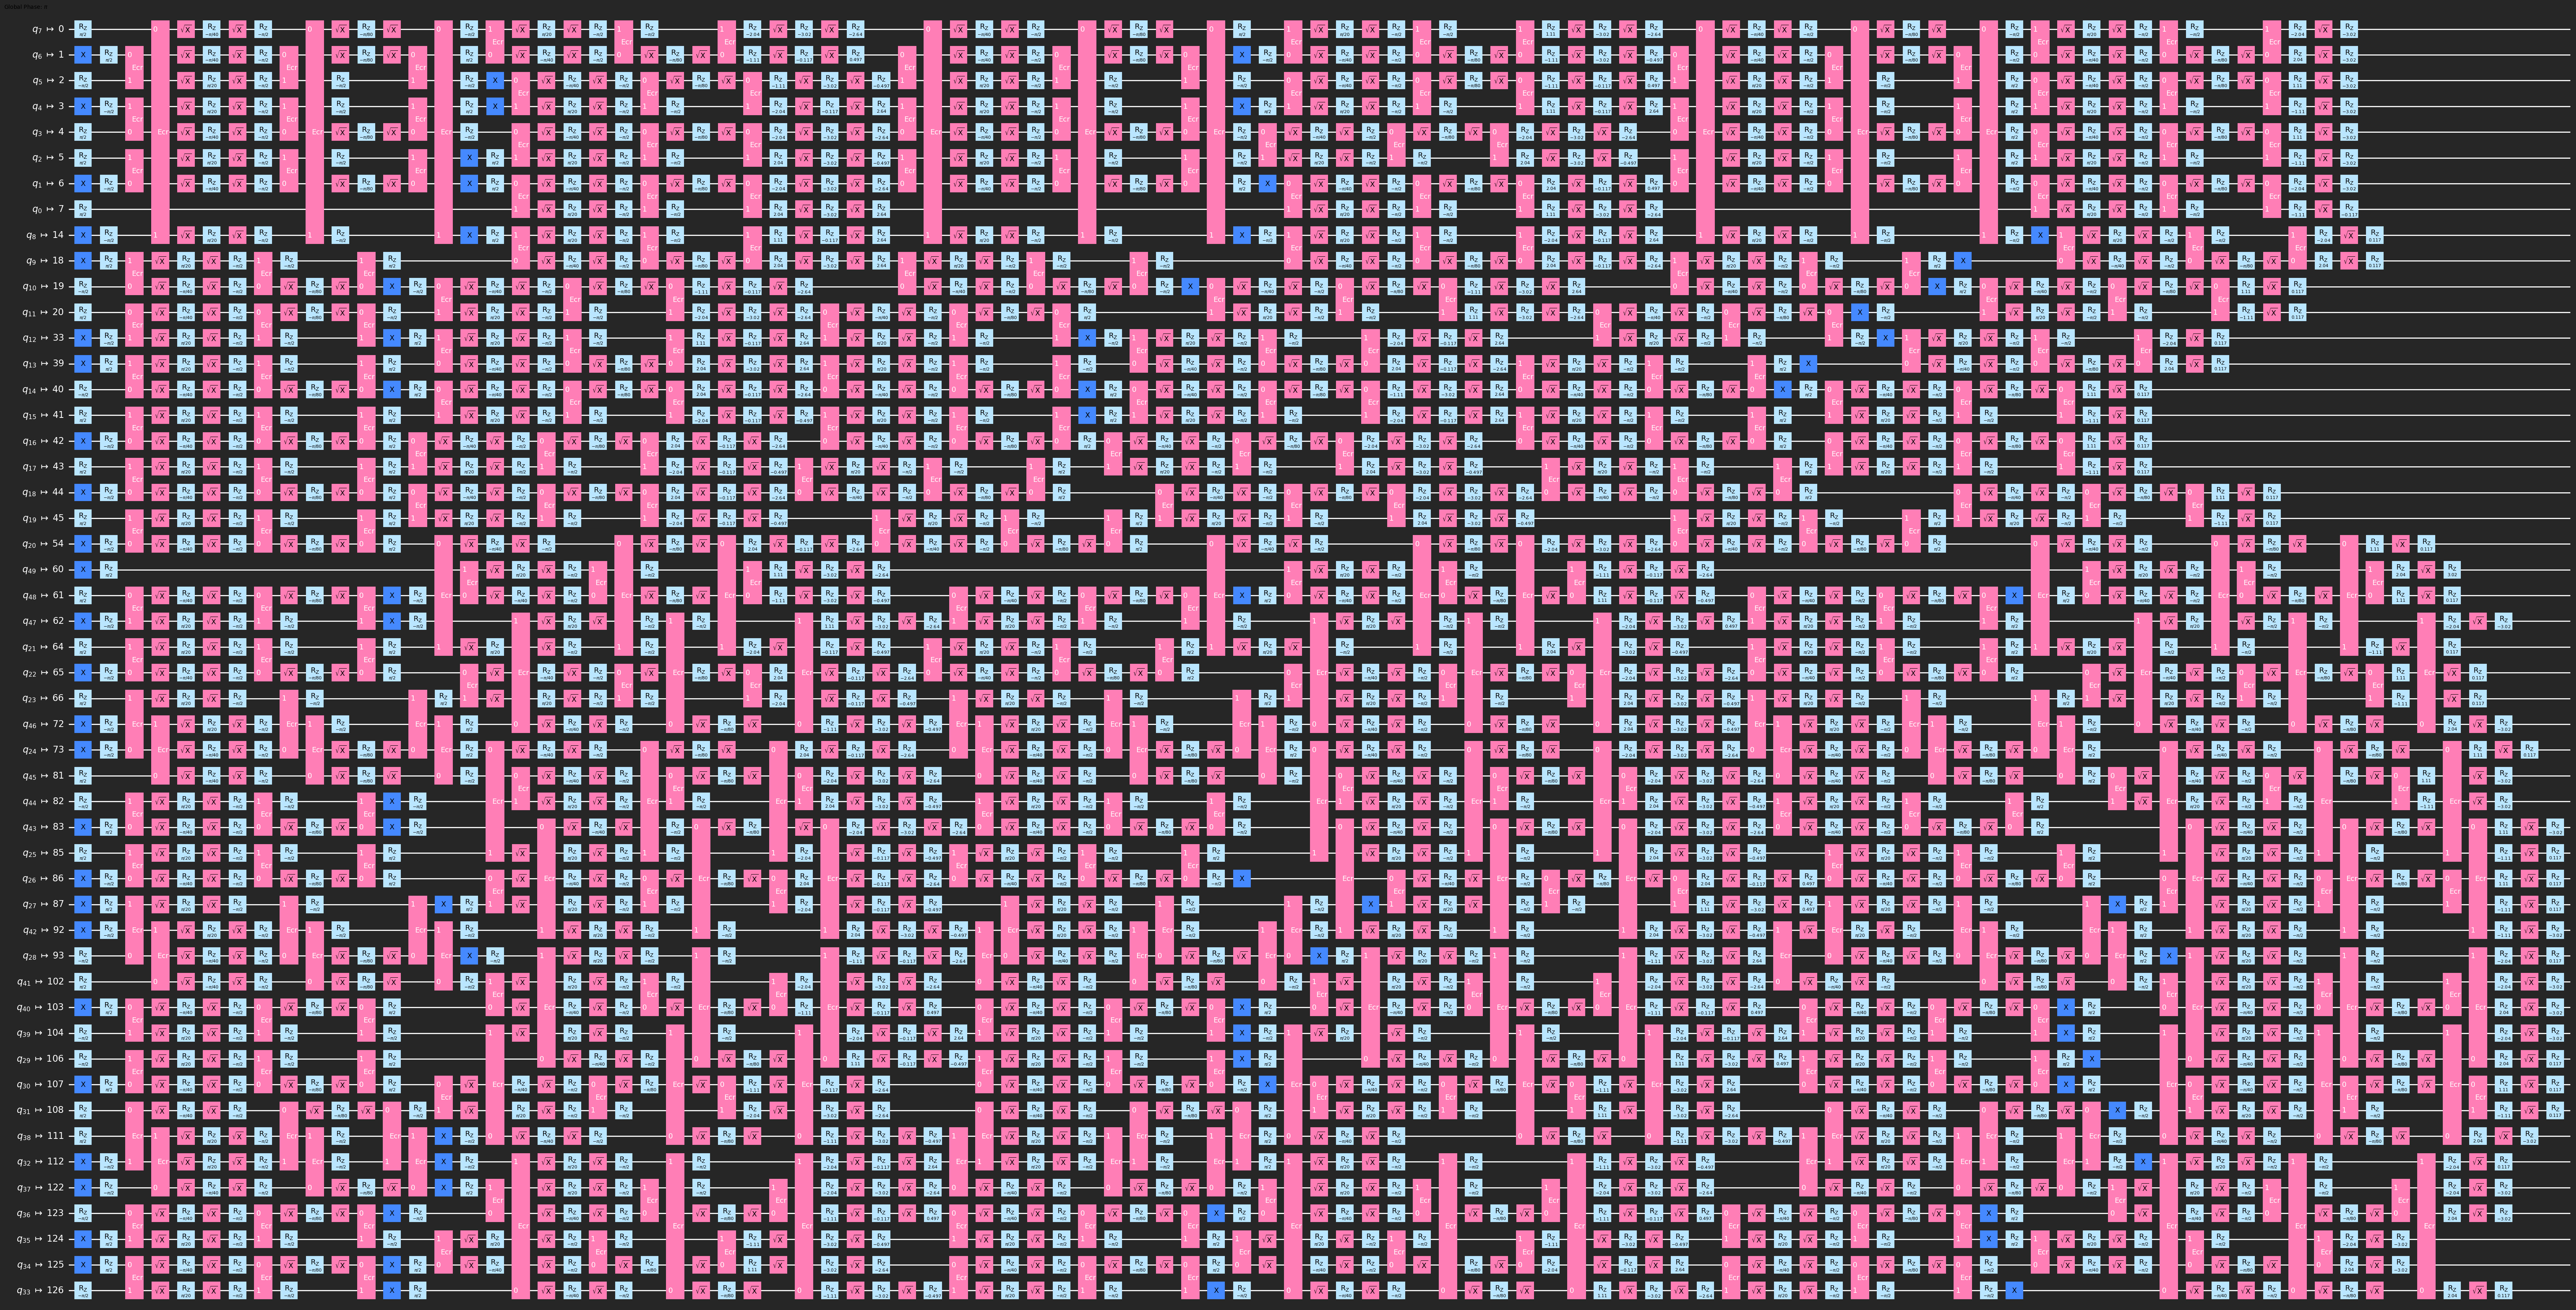

In [102]:
isa_circuit = results_transpiled['best_transpiled_circuit']
isa_observable = results_transpiled['best_transpiled_observable']

isa_circuit.draw("mpl", fold =-1, style='iqp-dark')

In [103]:
print(f"The transpiled backpropagated circuit has a depth of {isa_circuit.depth()} and 2-qubit depth of {isa_circuit.depth(lambda instr:instr.operation.num_qubits==2)}")

The transpiled backpropagated circuit has a depth of 81 and 2-qubit depth of 18


### Step 3: Execute using Qiskit primitives

In [33]:
pubs = [(isa_circuit,isa_observable)]

In [34]:
from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions
options = EstimatorOptions()
options.default_precision = 0.01
options.resilience_level = 2
options.resilience.zne.noise_factors = [1,1.2,1.4]
options.resilience.zne.extrapolator = ['linear']

estimator = EstimatorV2(mode=backend, options=options)

In [35]:
job = estimator.run(pubs)

In [37]:
job_id = job.job_id()
job_id

'd22715dmndjs73etedug'

In [38]:
result = job.result()[0]
print("Job done")

Job done


### Step 4: Post-process and return result in desired classical format

Finally, we now plot the expectation value obtained using backpropagation and compare it with the ideal expectation value.

In [39]:
bp_expval = round(float(result.data.evs),2)
bp_expval

0.95

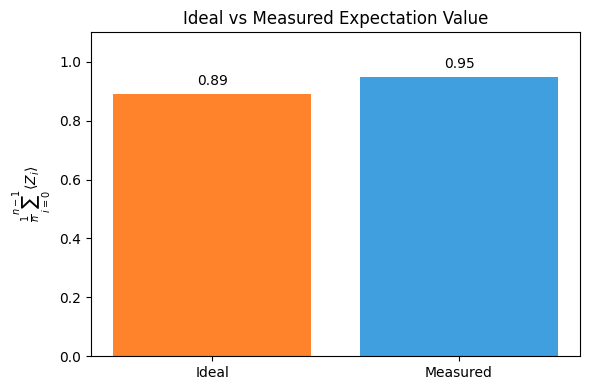

In [40]:
import matplotlib.pyplot as plt


labels = ['Ideal', 'Measured']
values = [0.89, bp_expval]

# Plotting
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#ff832b', "#3f9fdf"])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.ylim(0, 1.1)
plt.ylabel(r"$\frac{1}{n} \sum_{i=0}^{n-1} \langle Z_i \rangle$")
plt.title('Ideal vs Measured Expectation Value')

plt.tight_layout()
plt.show()
